In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: mps


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [5]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================

class PancakeMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(PancakeMLP, self).__init__()
        # 2 Hidden Layers, high neuron count
        self.fc1 = nn.Linear(input_size, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = x.view(-1, 784) 
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x



In [6]:
class TowerMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(TowerMLP, self).__init__()
        # 5 Hidden Layers, low neuron count, with Batch Norm
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        
        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)
        
        self.fc3 = nn.Linear(256, 256)
        self.bn3 = nn.BatchNorm1d(256)
        
        self.fc4 = nn.Linear(256, 256)
        self.bn4 = nn.BatchNorm1d(256)
        
        self.fc5 = nn.Linear(256, 256)
        self.bn5 = nn.BatchNorm1d(256)
        
        self.fc6 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.relu(self.bn4(self.fc4(x)))
        x = F.relu(self.bn5(self.fc5(x)))
        x = self.fc6(x)
        return x

In [7]:
class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()
        # Total parameters: ~652,175 (Leaner and more efficient)
        self.net = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.15), # Reduced from 0.2
            
            nn.Linear(512, 384), # Tapering down sooner
            nn.BatchNorm1d(384),
            nn.GELU(),
            nn.Dropout(0.15),
            
            nn.Linear(384, 128), # Bottleneck layer to force feature extraction
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.15),
            
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.net(x)

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T

def train_model(model, train_loader, val_loader, epochs=30, name='champion'):
    global DEVICE
    device = DEVICE
    model = model.to(device)
    
    # Reduced label smoothing to allow for higher confidence predictions
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
    
    # Reduced weight decay to balance the shorter epoch count
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
    
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=3e-3, 
        steps_per_epoch=len(train_loader), 
        epochs=epochs,
        pct_start=0.2
    )

    # Slightly milder spatial augmentation to preserve digit/object shapes
    augmenter = T.RandomAffine(degrees=10, translate=(0.08, 0.08))

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for images, labels in train_loader:
            # Spatial Augmentation
            images_2d = images.view(-1, 1, 28, 28)
            images_aug = augmenter(images_2d)
            images = images_aug.view(-1, 784).to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            scheduler.step()
            
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
        epoch_train_acc = 100 * train_correct / train_total
        epoch_train_loss = train_loss / train_total

        
        # Validation Phase
        model.eval()
        val_correct, val_total = 0, 0
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                val_loss += loss.item() * images.size(0)
                
        epoch_val_acc = 100 * val_correct / val_total
        epoch_val_loss = val_loss / val_total
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)

    torch.save(model.state_dict(), f"{name}_weights.pth")
    print("Training complete. Weights saved.")
    return history

In [45]:
# Pancake MLP
pancake_model = PancakeMLP()
pancake_history = train_model(pancake_model, train_loader, val_loader, epochs=40, name='pancake')

Epoch [1/40] | Train Acc: 44.14% | Val Acc: 60.52%
Epoch [2/40] | Train Acc: 59.13% | Val Acc: 67.12%
Epoch [3/40] | Train Acc: 64.75% | Val Acc: 70.66%
Epoch [4/40] | Train Acc: 67.53% | Val Acc: 72.51%
Epoch [5/40] | Train Acc: 68.88% | Val Acc: 70.20%
Epoch [6/40] | Train Acc: 70.46% | Val Acc: 74.24%
Epoch [7/40] | Train Acc: 71.04% | Val Acc: 74.24%
Epoch [8/40] | Train Acc: 71.78% | Val Acc: 74.12%
Epoch [9/40] | Train Acc: 73.03% | Val Acc: 76.73%
Epoch [10/40] | Train Acc: 74.39% | Val Acc: 75.97%
Epoch [11/40] | Train Acc: 75.29% | Val Acc: 77.03%
Epoch [12/40] | Train Acc: 75.88% | Val Acc: 77.17%
Epoch [13/40] | Train Acc: 76.07% | Val Acc: 78.42%
Epoch [14/40] | Train Acc: 76.89% | Val Acc: 77.28%
Epoch [15/40] | Train Acc: 77.12% | Val Acc: 78.88%
Epoch [16/40] | Train Acc: 77.95% | Val Acc: 78.63%
Epoch [17/40] | Train Acc: 78.33% | Val Acc: 79.33%
Epoch [18/40] | Train Acc: 78.77% | Val Acc: 79.85%
Epoch [19/40] | Train Acc: 78.88% | Val Acc: 79.85%
Epoch [20/40] | Train

In [46]:
# Tower MLP
tower_model = TowerMLP()
tower_history = train_model(tower_model, train_loader, val_loader, epochs=40, name='tower')


Epoch [1/40] | Train Acc: 46.59% | Val Acc: 63.90%
Epoch [2/40] | Train Acc: 62.27% | Val Acc: 68.75%
Epoch [3/40] | Train Acc: 65.98% | Val Acc: 70.74%
Epoch [4/40] | Train Acc: 67.46% | Val Acc: 72.20%
Epoch [5/40] | Train Acc: 68.90% | Val Acc: 71.97%
Epoch [6/40] | Train Acc: 70.19% | Val Acc: 74.21%
Epoch [7/40] | Train Acc: 71.44% | Val Acc: 73.80%
Epoch [8/40] | Train Acc: 72.55% | Val Acc: 75.03%
Epoch [9/40] | Train Acc: 73.75% | Val Acc: 76.26%
Epoch [10/40] | Train Acc: 74.73% | Val Acc: 76.98%
Epoch [11/40] | Train Acc: 75.21% | Val Acc: 77.55%
Epoch [12/40] | Train Acc: 75.48% | Val Acc: 77.35%
Epoch [13/40] | Train Acc: 76.44% | Val Acc: 77.26%
Epoch [14/40] | Train Acc: 76.59% | Val Acc: 78.60%
Epoch [15/40] | Train Acc: 77.31% | Val Acc: 78.87%
Epoch [16/40] | Train Acc: 77.73% | Val Acc: 79.34%
Epoch [17/40] | Train Acc: 78.49% | Val Acc: 79.51%
Epoch [18/40] | Train Acc: 78.72% | Val Acc: 79.74%
Epoch [19/40] | Train Acc: 79.21% | Val Acc: 80.07%
Epoch [20/40] | Train

In [36]:
champion_model = ChampionMLP()
champion_history = train_model(champion_model, train_loader, val_loader, epochs=30, name='champion')

Epoch [1/30] | Train Acc: 47.04% | Val Acc: 65.85%
Epoch [2/30] | Train Acc: 61.83% | Val Acc: 70.53%
Epoch [3/30] | Train Acc: 65.29% | Val Acc: 71.37%
Epoch [4/30] | Train Acc: 67.76% | Val Acc: 73.33%
Epoch [5/30] | Train Acc: 69.94% | Val Acc: 74.12%
Epoch [6/30] | Train Acc: 71.72% | Val Acc: 76.38%
Epoch [7/30] | Train Acc: 72.95% | Val Acc: 77.58%
Epoch [8/30] | Train Acc: 74.06% | Val Acc: 78.11%
Epoch [9/30] | Train Acc: 75.10% | Val Acc: 78.47%
Epoch [10/30] | Train Acc: 75.77% | Val Acc: 79.65%
Epoch [11/30] | Train Acc: 76.08% | Val Acc: 79.83%
Epoch [12/30] | Train Acc: 76.92% | Val Acc: 80.72%
Epoch [13/30] | Train Acc: 77.74% | Val Acc: 80.99%
Epoch [14/30] | Train Acc: 77.94% | Val Acc: 81.08%
Epoch [15/30] | Train Acc: 78.64% | Val Acc: 82.17%
Epoch [16/30] | Train Acc: 78.93% | Val Acc: 82.27%
Epoch [17/30] | Train Acc: 79.64% | Val Acc: 82.31%
Epoch [18/30] | Train Acc: 79.91% | Val Acc: 83.01%
Epoch [19/30] | Train Acc: 80.32% | Val Acc: 82.74%
Epoch [20/30] | Train

In [15]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.


In [16]:
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')

Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.


In [ ]:
# pancake_predictions = get_predictions(pancake_model, test_loader)
# tower_predictions = get_predictions(tower_model, test_loader)
champion_predictions = get_predictions(champion_model, test_loader)

submission_file = "champion_model_submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, champion_predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")

Saving predictions to 'champion_model_submission.txt'...
-> Copy & paste the results of this file to the portal.


In [43]:
def print_model_size(model, name='champion'):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics: {name}")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(pancake_model, 'pancake')
print_model_size(tower_model, 'tower')
print_model_size(champion_model, 'champion')
# print_model_size(champion_model_v2, 'champion_v2')


Model Statistics: pancake
  Total Parameters: 1,868,815
  ✅ Parameter count is within limits.

Model Statistics: tower
  Total Parameters: 470,543
  ✅ Parameter count is within limits.

Model Statistics: champion
  Total Parameters: 652,175
  ✅ Parameter count is within limits.


In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(history, model_name="Champion"):
    """
    Takes the history dictionary returned by train_model() and plots the curves.
    """
    epochs = range(1, len(history['train_acc']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning Curves: {model_name} Model', fontsize=16, fontweight='bold')

    # Plot Accuracy
    ax1.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
    ax1.plot(epochs, history['val_acc'], 'r--', label='Validation Accuracy', linewidth=2)
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend()

    # Plot Loss
    ax2.plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    ax2.plot(epochs, history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend()

    plt.tight_layout()
    plt.show()


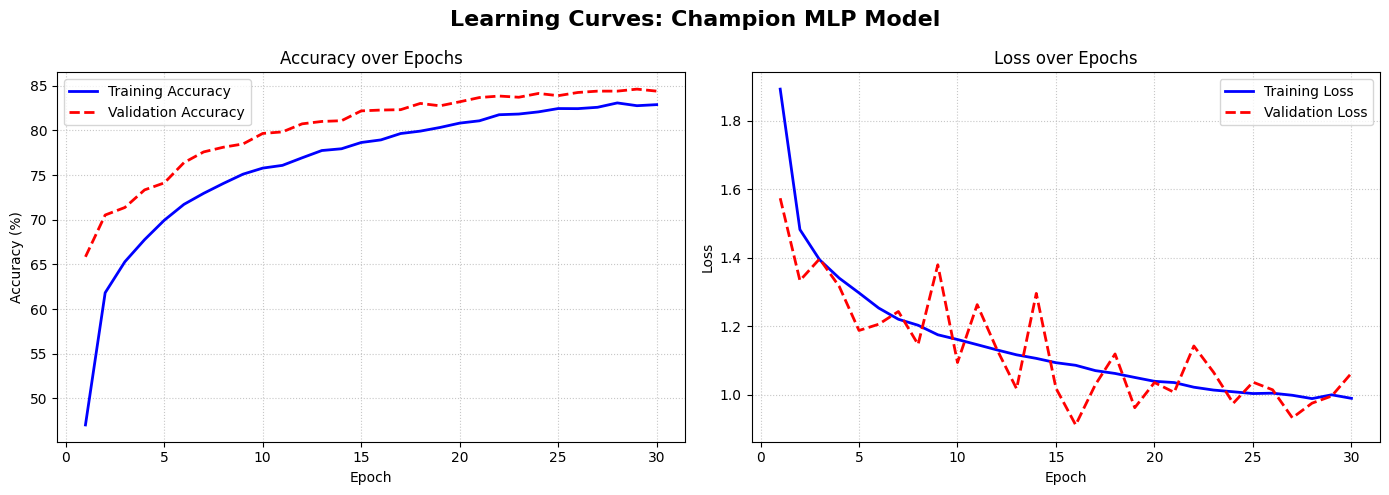

In [42]:
plot_learning_curves(champion_history, "Champion MLP")

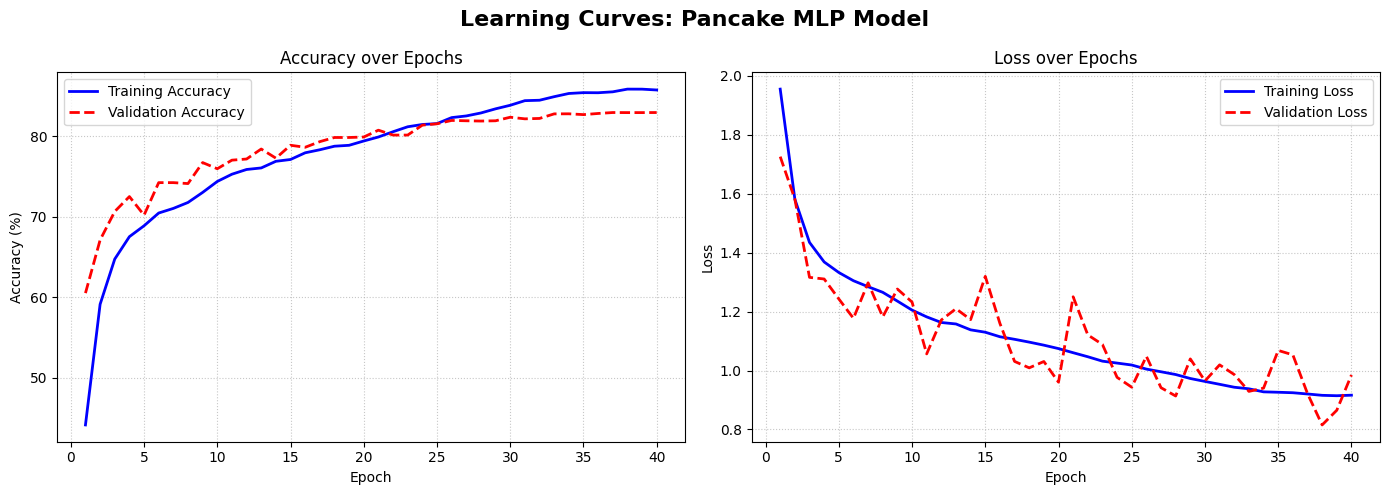

In [48]:
plot_learning_curves(pancake_history, "Pancake MLP")

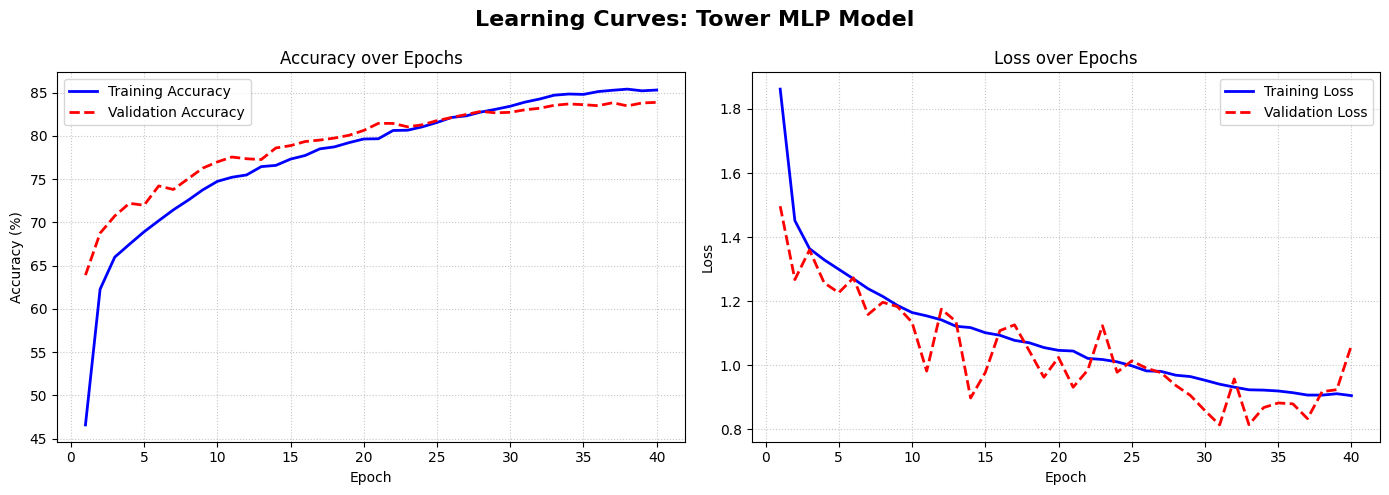

In [49]:
plot_learning_curves(tower_history, "Tower MLP")

In [55]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, val_loader):
    global DEVICE
    device = DEVICE
    
    CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 
               'cookie', 'donut', 'ladder', 'mountain', 'pizza', 
               'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']
    
    model = model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    print("Evaluating validation set for Confusion Matrix...")
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Generate the Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plotting
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title(f'Confusion Matrix - Champion Model', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Evaluating validation set for Confusion Matrix...


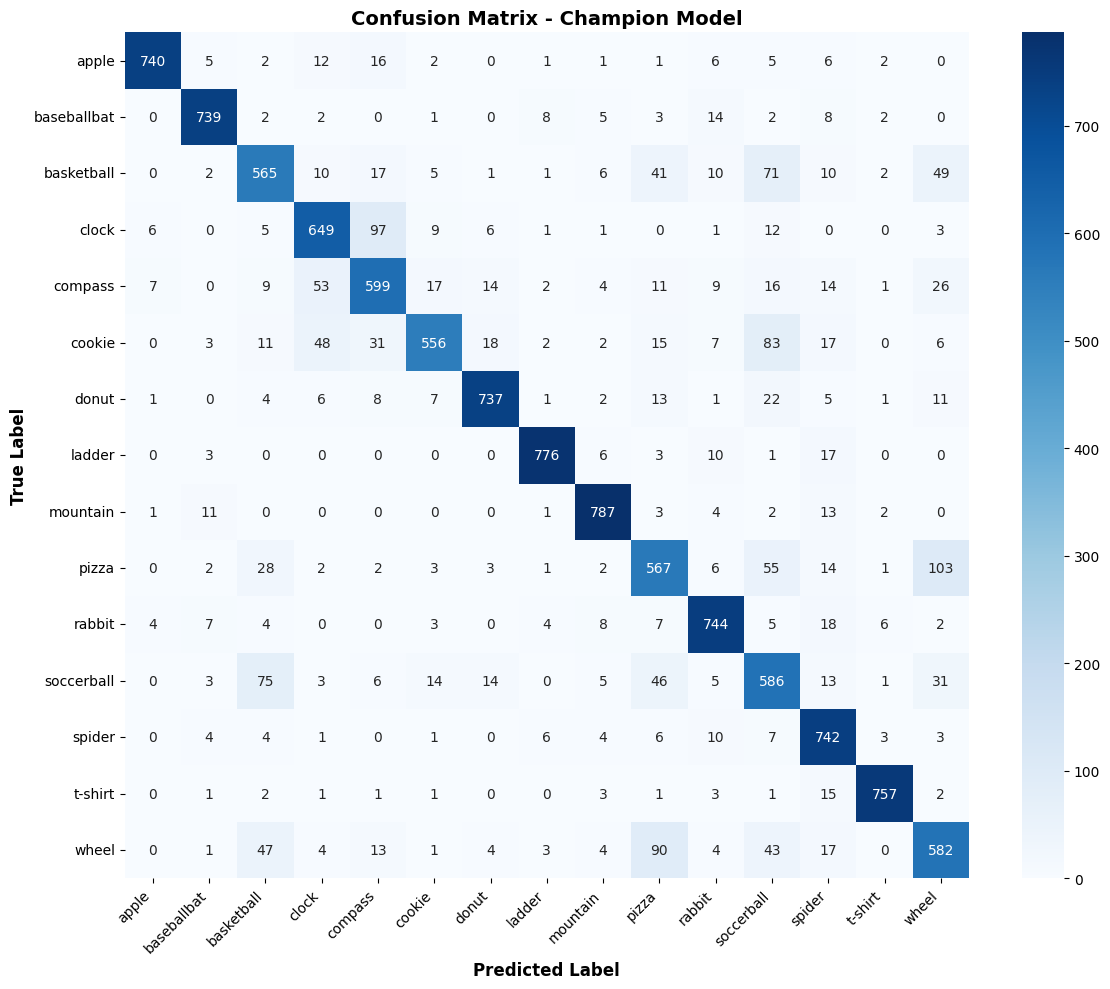

In [56]:
plot_confusion_matrix(champion_model, val_loader)